In [13]:
from mpmath.identification import transforms
from transformers import GPT2LMHeadModel
import os
from pathlib import Path

In [14]:
def get_local_model_path(model_name):

    hf_home = Path(os.environ.get('HF_HOME', str(Path.home() / '.cache' / 'huggingface')))

    if 'snapshots' in str(hf_home):
        parts = str(hf_home).split('snapshots')[0]
        hf_home = Path(parts).parent.parent  # Go up to the base huggingface cache

    model_cache = hf_home / 'hub' / f'models--{model_name.replace("/", "--")}'

    if not model_cache.exists():
        raise FileNotFoundError(f"Model {model_name} not found in cache at {model_cache}")

    snapshots_dir = model_cache / 'snapshots'
    if not snapshots_dir.exists():
        raise FileNotFoundError(f"Snapshots directory not found at {snapshots_dir}")

    snapshots = list(snapshots_dir.glob('*'))
    if not snapshots:
        raise FileNotFoundError(f"No snapshots found for {model_name}")

    return str(snapshots[-1])

<div align="center">

# **Hugging Face Local Model Path Resolver**

</div>

## Overview

The `get_local_model_path` function dynamically locates the snapshot directory containing model weights within the Hugging Face cache structure. This eliminates the need to hardcode system-specific paths in your code, making it portable and safe to share on GitHub.

## Prerequisites

- The model must already be cached locally (downloaded at least once while online)
- `transformers` library installed
- `TRANSFORMERS_OFFLINE=1` environment variable set (optional but recommended for offline work)

## Problem Statement

When loading pre-trained models offline using `transformers`, you need to point to the exact location of the model files (e.g., `model.safetensors`) within the cache directory:


In [15]:
model_path = get_local_model_path("gpt2")
model_hf = GPT2LMHeadModel.from_pretrained(
    model_path,
    local_files_only=True
)

sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

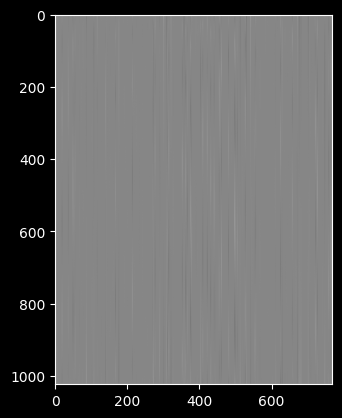

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

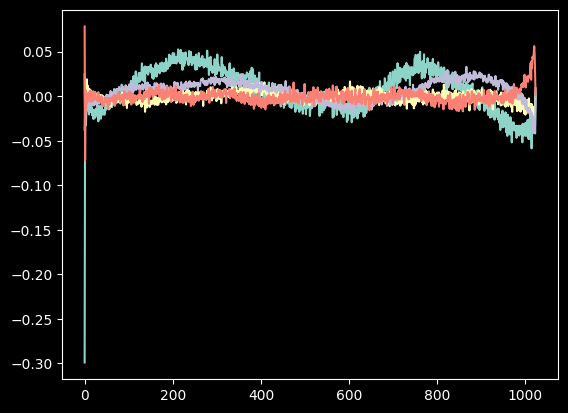

In [17]:
plt.plot(sd_hf["transformer.wpe.weight"] [:, 67])
plt.plot(sd_hf["transformer.wpe.weight"] [:, 178])
plt.plot(sd_hf["transformer.wpe.weight"] [:, 256])
plt.plot(sd_hf["transformer.wpe.weight"] [:, 384])

In [18]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation' , model=model_path)
set_seed(42)
generator('I play electric guitar', max_length=30, num_return_sequences=5)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "I play electric guitar for a living. When I'm not playing, I play a lot of bass and guitar. So maybe when I'm at home in the summer, I'll play a lot of electric guitar. I'd probably play a lot of bass.\n\nIt's always been a challenge to get a good guitar with the right setting. I have a guitar with me in my house that I like to play, and I'll go into a room that I like to play and I'll play a lot of electric guitars. I play a lot of bass and guitar and I feel like I have a lot of energy. I'll play a lot of electric guitars. I'm a very competitive spirit, and I don't want to be that.\n\nSo I guess it's just a matter of finding a good guitar for the right situation. I feel like I'd be better off playing a guitar that I really like, playing electric guitar, if I could play a little bit electric guitar.\n\nWould you get involved in politics or activism if you could play a lot of electric guitar?\n\nI'm a small-town, moderate, conservative, libertarian, and I'm not a po